In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

Load Dataset

In [2]:
df = pd.read_csv('Menu.csv')

df.head()

,Menu_id,Restaurant_id,Food_id,Cuisine,Price
0,mn0,567335,fd0,"Beverages,Pizzas",40.0
1,mn0,567335,fd669322,"Beverages,Pizzas",40.0
2,mn328,158203,fd0,Beverages,65.0
3,mn328,158203,fd669322,Beverages,65.0
4,mn449,158203,fd0,Beverages,65.0


Dataset Overview

In [3]:
df.shape 

(1048574, 5)

In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Menu_id        1048574 non-null  object 
 1   Restaurant_id  1048574 non-null  int64  
 2   Food_id        1048574 non-null  object 
 3   Cuisine        1048574 non-null  object 
 4   Price          1048574 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 40.0+ MB


In [5]:
df.columns

Index(['Menu_id', 'Restaurant_id', 'Food_id', 'Cuisine', 'Price'], dtype='object')

Statistical Summary

In [6]:
df.describe()

,Restaurant_id,Price
count,1.048574e+06,1.048574e+06
mean,3.171527e+05,1.969102e+02
std,1.782940e+05,1.705025e+02
min,2.110000e+02,0.000000e+00
25%,1.321680e+05,1.000000e+02
50%,3.552390e+05,1.600000e+02
75%,4.808060e+05,2.490000e+02
max,5.806910e+05,9.999000e+03


Missing Values

In [7]:
df.isnull().sum()

Menu_id          0
Restaurant_id    0
Food_id          0
Cuisine          0
Price            0
dtype: int64

Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

C:\Users\Chandubhai Chotaliya\AppData\Local\Temp\ipykernel_10504\2907331251.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [10]:
df.dtypes

Menu_id           object
Restaurant_id      int64
Food_id           object
Cuisine           object
Price            float64
dtype: object

Separate Numerical & Categorical Columns

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Restaurant_id', 'Price'], dtype='object')
Categorical Columns: Index(['Menu_id', 'Food_id', 'Cuisine'], dtype='object')


Univariate Analysis

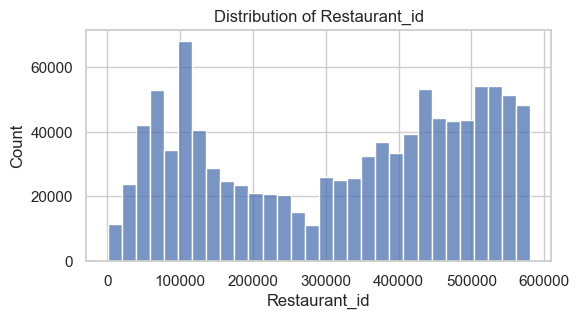

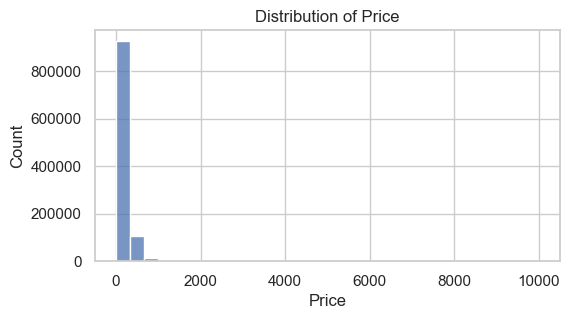

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

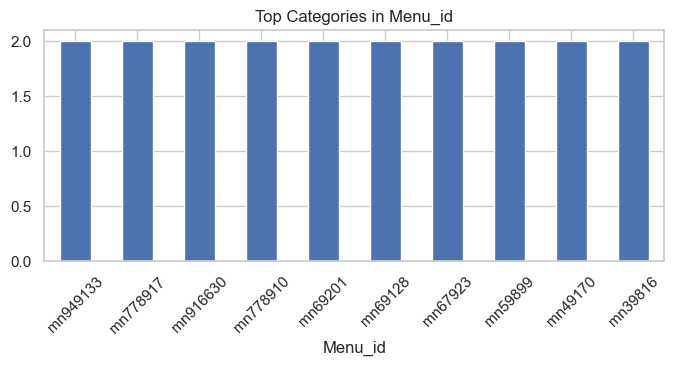

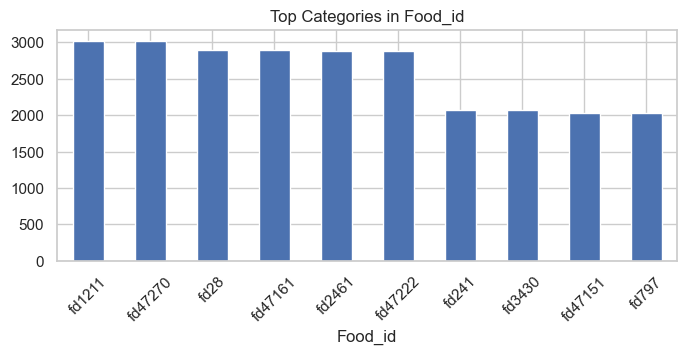

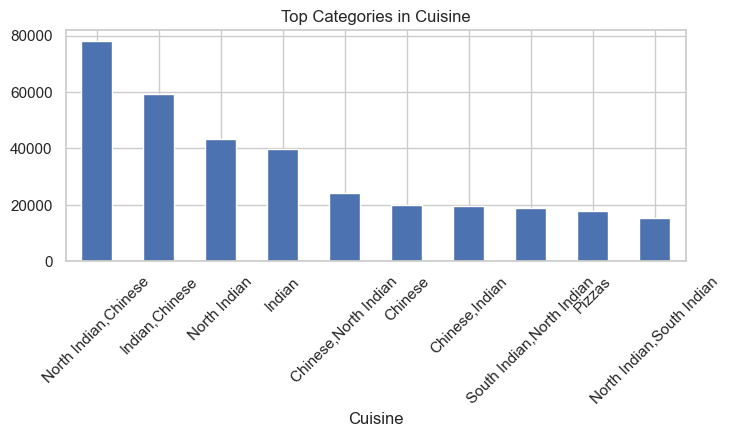

In [14]:
for col in cat_cols:
    plt.figure(figsize=(8,3))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xticks(rotation=45)
    plt.show()


Bivariate Analysis

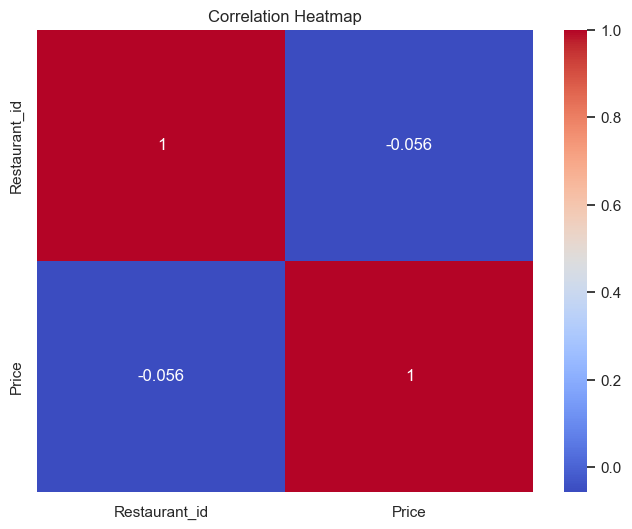

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
